# Research Assistant Agent: Agent built with LLM , Parallelization, sub-graph, persistance, map-reduce

    Agentic system that takes a user‑defined topic, generates subtopics, creates expert analyst personas, conducts automated interviews, performs web and Wikipedia retrieval or RAG for answers, and generates individual technical reports with deep insights which are further synthesized into a polished, citation‑ready final research report.

### Goal : Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.
- Research Agent that researches a topic, interviews top‑class expert personas, retrives answers from the documents returned from the websearch, and generates a polished technical report.


### Why This Project Matters
This project showcases how agentic AI systems can move beyond simple Q&A and perform multi‑step reasoning, evidence gathering, and structured synthesis. It demonstrates:

- How to build reliable subgraphs
- How to manage state across complex workflows
- How to combine retrieval + reasoning + writing
- How to maintain determinism and avoid state conflicts
- It’s a practical blueprint for building research assistants, analyst copilots, or automated reporting tools.

### Workflow:

`Topic Selection :`
- Users can choose any input topic for their research.

`Planning : `
- system generates a team of AI analysts or analyst personas, each focusing on one sub-topic.
- Analyst are specialized and expersts in the area of interest.
- Human-in-the-loop will be used to refine these sub-topics as well as analysts area of interest before research begins.

`LLM Utilization: `
- Each analyst will conduct in-depth interviews with an expert AI on their expertice gaining deep insights into their topic of interest.
- The interview will be a multi-turn conversation to extract detailed insights.
- These interviews will be captured in a using sub-graphs with their internal state.

`Research Process: `
- Experts will gather information to answer analyst questions in parallel using RAG or web/wiki search.
- And all interviews will be conducted simultaneously through map-reduce.

`Output Format:`
- The gathered insights from each interview will be synthesized into a final report.
- Customizable prompts are used throughout from analyst creation to generating final report, allowing for a flexible output format.
- sources are included in the report for authenticity.
- Detailed Interview , Expert Analist List,  Final report are provided as an output to the user.



In [2]:
# set up environmnet
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [3]:
# creat llm
from google import genai
from langchain_google_genai import ChatGoogleGenerativeAI

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/antigravity-preview-05-2026
models/

In [5]:
# creat llm
llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHaUaSHr41VLszPinmvz6d3n/x1LCnf8INqVCVhb1VfPYVu9KuMrsIO8k2B44d'}}]

In [3]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

### Step 1: Create analysts depending on the topic and subtopic and human feedback.

##### Workflow : 
1. Create nodes to generate 3 subtopics based onthe topic given
2. get human feedback on the subtopics
3. create analysts specialized in the subtopic domain
4. Get feedback on the analysts

In [6]:
from typing_extensions import TypedDict, Annotated , List
from operator import add

# create pydantic analyst blueprint
from pydantic import BaseModel ,Field

class Analyst(BaseModel):
    name:str = Field(description="Name of the analyst.")
    role:str = Field(description="Role of the analyst in the context of the topic.",)
    affiliation:str = Field(description="Primary affiliation of the analyst.",)
    description: str = Field(description="Description of the analyst focus, concerns, and motives.",)

    @property
    def persona(self)->str:
        return f"Analyst Name:{self.name}\n Role:{self.role}\n Affiliation: {self.affiliation}\n Description: {self.description}\n"
    
# create aoverall class
class overallState(TypedDict):
    topic: str
    subtopics:List[str]
    max_analyst:int
    subtopic_feedback:str
    human_analyst_feedback: str
    analysts : List[Analyst] # List[Analyst.persona* max_analyst] / annotated for persistance
    #technical_report: Annotated[list[str],add]  # map-reduce : spend API- technical report from various analysts interviewd in subgraph



#wraper for generating a list of analysts for structured output (important)
class AnalystList(BaseModel):
    analysts: List[Analyst]

    

In [7]:
# create node functions
# blueprint for llm output
class subtopic(BaseModel):
    subtopic: List[str]

#create a node to ask user for a topic
def get_topic(state:overallState):
    topic = input("What Topic are you interested in exploring and generating a report on? We have expert Analysts team to genetate reports for you based on your topic.\n Your topic: ")
    return {**state, 'topic': topic }
    
# generate sub topics    
def get_subtopic(state:overallState):
    '''generate listof subtopics'''
    topic = state['topic'];
    sub_topic_prompt = f"create a list of 3 distinct subtopics for the topic:'{topic}' provided."
    response = llm.with_structured_output(subtopic).invoke(sub_topic_prompt)
    return {'subtopics': response.subtopic }

# subtopic refining before search using dynamic breakpoint
from langgraph.types import interrupt

def Human_feedback_refine_Subtopic(state:overallState):
    '''generate subtopic feedback'''
    #print(f"Sub Topics are: {state['subtopics']}")
    
    subtopic_feedback = state.get('subtopic_feedback' , None)
    if subtopic_feedback:
        subtopic_feedback_prompt = f"based on the feedback given by the expert here:'{subtopic_feedback}', re-adjust and re-create subtopics {state['subtopics']} accordingly. Ensure utmost correspondance to the original Topic"
        response = llm.with_structured_output(subtopic).invoke(subtopic_feedback_prompt)
        return { 'subtopics': response.subtopic }
    else:
        return state

# create analysts
analyst_prompt = """You are AI Analytic supervisor who is tasked with creating expert AI analysts and and assigning role for each subtopic provided. 
    Create AI analyst personas while following the following instructions clearly.
    1. Review the main topic{topic} and the subtopics {sub_topics}
    2. Examin and consider any editorial Human feedback provided as a guide to create the analysts : {human_analyst_feedback}
    3. determine the most interesting theme for each subtopic based on the document and or feedback.
    5. Create and assign the best analyst for each subtopic and or theme selected. create {max_no} analysts.
    6. Names and roles must be globally unique across all subtopics or themes(examaple for names: Dr. Alia Bhat , Dr. Devesh Patel, Dr.Jassica etc).
    8. Analyst must be highly qualified and exceptional."""

from langchain_core.messages import SystemMessage , HumanMessage    
def create_analysts(state:overallState):
    '''create unique anlysts according to the blueprint'''
    
    sys_instr = SystemMessage(content= analyst_prompt.format(topic = state['topic'] , sub_topics = state['subtopics'] , human_analyst_feedback = state.get('human_analyst_feedback', None), max_no = state['max_analyst']))
    Human_instr = HumanMessage(content="Generate a set of analysts. Carefully follow the system intruction")
    
    #print(f"subtopics: {state['subtopics']}")   
    response = llm.with_structured_output(AnalystList).invoke([sys_instr] +[ Human_instr])
    #print(f"Feedback : {state.get('human_analyst_feedback', None)}")
    return {'analysts':response.analysts}


# get human feedback on analyst selection
def analyst_feedback(state:overallState):
    ''' get feedback on the analysts for enhancemeent and change'''
    print("Enter your feedback on the analyst assignment. specify any changes.")
    pass

# continue to assign analyst
def continue_with_Feedback(state:overallState):
    ''' continue to create analyst node if feedback exists'''
    feedback = state.get('human_analyst_feedback' , None)
    if feedback:
        return 'create_analysts'

    return END    

##### build graph

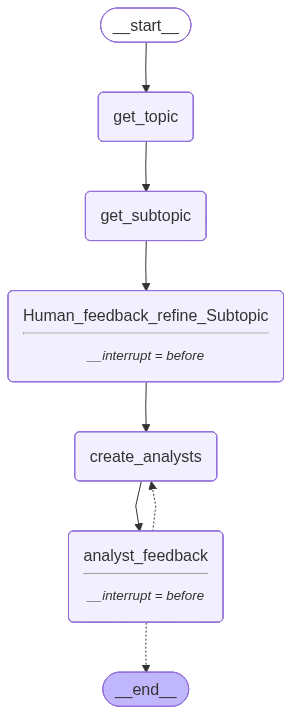

In [8]:
from langgraph.graph import StateGraph , START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
checkpointer = MemorySaver() 

builder = StateGraph(overallState)

# add nodes
builder.add_node('get_topic' , get_topic)
builder.add_node('get_subtopic' , get_subtopic)
builder.add_node('Human_feedback_refine_Subtopic' , Human_feedback_refine_Subtopic)
builder.add_node('create_analysts' , create_analysts)
builder.add_node('analyst_feedback' , analyst_feedback)

# add edges
builder.add_edge(START, 'get_topic')
builder.add_edge('get_topic', 'get_subtopic')
builder.add_edge('get_subtopic', 'Human_feedback_refine_Subtopic')
builder.add_edge('Human_feedback_refine_Subtopic', 'create_analysts')
builder.add_edge('create_analysts', 'analyst_feedback')
builder.add_conditional_edges('analyst_feedback', continue_with_Feedback, ['create_analysts' , END] )
builder.add_edge('create_analysts', END)


memory = MemorySaver()
graph = builder.compile(interrupt_before=['Human_feedback_refine_Subtopic','analyst_feedback'], checkpointer=memory)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


### Debug by invoking the graph

In [9]:
config = {'configurable': {'thread_id': 'G3'}}
events = []
for event in graph.stream({'max_analyst':3} , config=config, stream_mode="values"):
    events.append(event)
    print(event)
    print("-"*45)
    

{'max_analyst': 3}
---------------------------------------------


What Topic are you interested in exploring and generating a report on? We have expert Analysts team to genetate reports for you based on your topic.
 Your topic:  k


{'topic': 'k', 'max_analyst': 3}
---------------------------------------------
{'topic': 'k', 'subtopics': ['K-pop music industry trends', 'Potassium chemical properties and biological roles', 'The letter K in linguistics and phonetics'], 'max_analyst': 3}
---------------------------------------------


In [ ]:
graph.get_state(config)

### Check for what node comes next:
breakp[oint @ 'Human_feedback_refine_Subtopic'

In [9]:
graph.get_state(config).next

('Human_feedback_refine_Subtopic',)

### review subtopics and suggest changes

In [124]:
graph.get_state(config).values

{'topic': 'k',
 'subtopics': ['Kinetic energy principles',
  'Keyboard layout evolution',
  'Kinesiology and human movement'],
 'max_analyst': 3,
 'technical_report': []}

### provide feedback/ update state

In [13]:

graph.update_state(config , {'subtopic_feedback': "Looks good! continue.."},as_node="Human_feedback_refine_Subtopic")

{'configurable': {'thread_id': 'G3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f155313-265c-61f5-8003-cbcb1be084e6'}}

### run the graph

In [14]:
events = []
for event in graph.stream(None , config , stream_mode="values"):
    events.append(event)
    print(event)
    print("-"*50)

{'topic': 'What is the best Agent framework?', 'subtopics': ['Comparison of LangChain versus AutoGPT for autonomous task execution', 'Evaluating the performance of CrewAI in multi-agent orchestration', 'Key architectural differences between Microsoft AutoGen and open-source alternatives'], 'max_analyst': 3, 'subtopic_feedback': 'Looks good! continue..', 'technical_report': []}
--------------------------------------------------
Feedback : None
{'topic': 'What is the best Agent framework?', 'subtopics': ['Comparison of LangChain versus AutoGPT for autonomous task execution', 'Evaluating the performance of CrewAI in multi-agent orchestration', 'Key architectural differences between Microsoft AutoGen and open-source alternatives'], 'max_analyst': 3, 'subtopic_feedback': 'Looks good! continue..', 'analysts': [AnalystList(analysts=[Analyst(name='Dr. Elena Vance', role='Autonomous Systems Architect', affiliation='Institute for Advanced Robotics and AI', description="Specializes in the compara

### check state:
- examin next node
- provide information if requested
- continue with the graph

In [15]:
state =graph.get_state(config)
print(state)

Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


StateSnapshot(values={'topic': 'What is the best Agent framework?', 'subtopics': ['Comparison of LangChain versus AutoGPT for autonomous task execution', 'Evaluating the performance of CrewAI in multi-agent orchestration', 'Key architectural differences between Microsoft AutoGen and open-source alternatives'], 'max_analyst': 3, 'subtopic_feedback': 'Looks good! continue..', 'analysts': [AnalystList(analysts=[Analyst(name='Dr. Elena Vance', role='Autonomous Systems Architect', affiliation='Institute for Advanced Robotics and AI', description="Specializes in the comparative analysis of agentic workflows, focusing on the trade-offs between LangChain's modularity and AutoGPT's autonomous goal-seeking capabilities."), Analyst(name='Dr. Marcus Thorne', role='Multi-Agent Orchestration Specialist', affiliation='Global Distributed Systems Laboratory', description="Expert in evaluating collaborative intelligence frameworks, with a specific focus on benchmarking CrewAI's performance in complex, m

### What's next?
- Check out the created Analysts
- What node exists next?
- provide the feedback on created list of Analysts if required and then run the graph
- If no feedback, just run the graph

In [16]:
state.next

('analyst_feedback',)

In [17]:
for a in state.values['analysts']:
    for a in a.analysts:
        print(a)
        print("-"*40)

name='Dr. Elena Vance' role='Autonomous Systems Architect' affiliation='Institute for Advanced Robotics and AI' description="Specializes in the comparative analysis of agentic workflows, focusing on the trade-offs between LangChain's modularity and AutoGPT's autonomous goal-seeking capabilities."
----------------------------------------
name='Dr. Marcus Thorne' role='Multi-Agent Orchestration Specialist' affiliation='Global Distributed Systems Laboratory' description="Expert in evaluating collaborative intelligence frameworks, with a specific focus on benchmarking CrewAI's performance in complex, multi-agent task delegation and role-based execution."
----------------------------------------
name='Dr. Sarah Jenkins' role='Framework Infrastructure Analyst' affiliation='Open Source AI Foundation' description="Focuses on the underlying architectural paradigms of agent frameworks, analyzing the technical divergence between Microsoft AutoGen's conversational patterns and various open-source 

In [18]:
graph.update_state(config, {'human_analyst_feedback': "Add in someone from a startup to add an entrepreneur perspective" } , as_node= 'analyst_feedback')


Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


{'configurable': {'thread_id': 'G3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f155314-81d5-6115-8005-f456e76c3442'}}

### run node after updating the state
- check if the feedback is used in the response

In [19]:
for event in graph.stream(None , config , stream_mode="values"):
    for analyst in event['analysts'][-1].analysts:
        print(analyst)
        print("-"*50)

Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


name='Dr. Elena Vance' role='Autonomous Systems Architect' affiliation='Institute for Advanced Robotics and AI' description="Specializes in the comparative analysis of agentic workflows, focusing on the trade-offs between LangChain's modularity and AutoGPT's autonomous goal-seeking capabilities."
--------------------------------------------------
name='Dr. Marcus Thorne' role='Multi-Agent Orchestration Specialist' affiliation='Global Distributed Systems Laboratory' description="Expert in evaluating collaborative intelligence frameworks, with a specific focus on benchmarking CrewAI's performance in complex, multi-agent task delegation and role-based execution."
--------------------------------------------------
name='Dr. Sarah Jenkins' role='Framework Infrastructure Analyst' affiliation='Open Source AI Foundation' description="Focuses on the underlying architectural paradigms of agent frameworks, analyzing the technical divergence between Microsoft AutoGen's conversational patterns and 

### check for analysts
    

In [20]:
state_new = graph.get_state(config)
for analyst in state_new.values['analysts'][-1].analysts:
    print(analyst)
    print("-"*50)
    

Deserializing unregistered type __main__.AnalystList from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'AnalystList')]


name='Dr. Silas Thorne' role='Autonomous Systems Architect' affiliation='Institute for Advanced Robotics' description='Specializes in the theoretical frameworks of autonomous agents, focusing on the comparative reliability and decision-making logic between LangChain and AutoGPT.'
--------------------------------------------------
name='Elena Vance' role='Multi-Agent Systems Engineer' affiliation='Global Tech Research Lab' description="Expert in distributed computing and swarm intelligence, dedicated to benchmarking CrewAI's orchestration capabilities in complex, high-throughput environments."
--------------------------------------------------
name='Marcus Sterling' role='Startup Founder and AI Strategy Consultant' affiliation='Velocity Ventures' description='An entrepreneur focused on the practical, cost-effective implementation of agent frameworks, evaluating Microsoft AutoGen against open-source alternatives for rapid product scaling and market viability.'
---------------------------

### End of analyst creation 

## Conduct Interview

Create a subgraph where each analysts are Interviewed on their focus of interest , answers are extracted through RAG or websearch and Technical reports are generated by each analyst.

### Workflow:
- `Generate questions :`

      - Use LLM to generate 2 sentence interview question based on the topic of interest.
      - Generate questions while deeply understanding and gaining deep insights in the topic of expertice. 
      - Ensure to cover important facts while gaining deep insight into the topic

- `Prepare context:`
    - Based on the questions , create llm querries to  websearch and gather information.
    - perform parallalization with research on the topic : Tavily and Wikipedia
    - build context using the research topics

- `Answer questions:`
    - Answer the questions based on the context and documents provided.
    - make sure llm does not hallucinate or gather information outside the documentation
    - Ensure answer is easily understood and brief.

-  Save as an Interview:
    - consolidate the questions and answers as  document the interivew in string format
      
- Report Generation:
    - Based on the documents extracted from the web and wiki, generate a technical report or a memo.

  

## Generate Questions : Questions asked by the interviewer on the topic provided

Goal: 
- Create nodes to generate questions on the topic provided
- Ensure questions uncover deep insights from the domain of interest

In [10]:
# create a new interivew_class
from langgraph.graph import MessagesState

class interview_state(MessagesState):
    max_turns: int # max number quetions generation round
    analyst : Analyst # analyst asking questions
    questions = List[str] # conversation  between the expert and anlyst with questions
    context: Annotated[List[str] , add] # documents based on the interview questions
    interview: List[str] # interview between the analyst and the expert
    technical_report: list[str]  # technical report from various analysts




# system intruction for the llm for the deep knowledge of the topic and questions to ask
interview_intruction = ''' You are an AI interivewer analyst tasked with genrating questions for the interview in analysts 
                            domain or area of expertice to gain deep insights on a given topic.
                            Your goal is to boil down and extract deep rooted information on  the topic by keeping foucus on the set of goal: {Analyst_personaInfo_goal} . 
                            ask interesting and insightful question while undertanding the concept and domain deeply keeping the goal in mind, especialy role and description of the expert.
                            1. Ensure the questions are insightful, out of the box and non-obvious and surprises people and enhances their knowlegde.
                            2. Ensure questions are easy to read and unsertand but deep and insightful.
                            3. Ensure questions do not exeed 2 sentences as it looses focus. 
                            4. Ensure topic of focus or set of goal is the given topic and the Analysts domain of expertice : {Analyst_personaInfo_goal}
                            5. Interview structure: Begin by introducing yourself as an Analyst with a name that fits your persona.
                            6. Ask questions to the expert on their domain expertice (do not deviate from the topic or the role and description provided)
                            7. continue asking questions to drill down deep and refine your understanding of the topic.
                            8. When you are satisfied with your undestanding, complete the interview with 'Thank you so much for your time and help!'
                            9.  Remember to stay in charecter throughout this interview, reflecting the persona and stay focused on the goal provided to you.
                            10. Do not be too verbose in asking question. keep the question easy and engaing.
                            11. Ensure questions are not empty or contain any symbols. use plain natural language.
                              '''

# create a node to generate quetions that loops to ask multiple questions
from langchain_core.messages import HumanMessage, SystemMessage , AIMessage

#Structured output for llm
class Questionair(BaseModel):
    question: str

    
def generate_questions(state:interview_state):
    # get state and create a messages field
    analyst = state['analyst']
    messages = state['messages']
    #topic = state['topic'] 
    
    # generate questions
    syst_msg = [SystemMessage(content=interview_intruction.format(Analyst_personaInfo_goal = analyst.persona))]

    response = llm.with_structured_output(Questionair).invoke(syst_msg + messages)
    
    question = HumanMessage(content=response.question , name = 'Interviewer')
    #print(f"Analyst: {analyst}")
    return {'messages': [question]}                  

    

# Generate Answer for the interview questions
## Parallelization: Gather information for the questions generated . Use it as a source to answer questions.

Goal: 
- create node functions to gather information about the questions asked by the interviewer using Tavily nd wiki
- Use parallel nodes to perform this action
  
For example, we can use:

- Specific web sites e.g., via WebBaseLoader
- Indexed documents e.g., via RAG
- Web search
- Wikipedia search
You can try different web search tools, like Tavily.


In [11]:
# Set Tavily on jupyter notebook
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# import tavily and wikipedia
from langchain_tavily import TavilySearch
from langchain_community.utilities import WikipediaAPIWrapper


tavily_search = TavilySearch(max_results=3)

## Workflow:
- create nodes to search the web and wikipedia.
- use LLm for crating search query based on the interview questions to search the internet
- create a node to answer analyst questions.
- Finally, create nodes to save the full interview and to write a summary ("section") of the interview.
#### 1. Generate Documents and context

In [27]:
# create a basemodel for structured output
class Search_Query(BaseModel):
    search_query:str = Field(None, description="Search query for retrieval.")

    
# create search instructions for llm Sear query
searchQuery_intruction = ''' You will be given conversation between the analyst and an expert on a specific topic. 
                            You goal is to create a detailed, well structured 'search query' to retrive information or websearch based on the conversation or the questions posed.
                            1. Analyze the full conversation.
                            2. Pay perticular attension to final question posed by the analyst,
                            3. Convert this final question into a well structured web search query
                            4. Ensure query can retrive deep and insightful information form the web'''

# search querry

    
def web_search_withTavily(state:interview_state):
    ''' retrive information using Tavily web search tool'''
    
    messages = state['messages']
    syst_instr = SystemMessage(content=searchQuery_intruction)
    human_msg ="Generate a best search query based on the questions asked and system instructions provided"
    
    # create structured output using BaseModel class
    structured_output = llm.with_structured_output(Search_Query)

    #using llm to build search query based on the conversation questions
    #response = structured_output.invoke([syst_intr] + messages)
    #print("Search_querry: ", response.search_query)
    no_result = True
    
    while (no_result == True):
        # get system and Human instruction            
        human_instr = HumanMessage(content=human_msg)
        
        # get response
        response = structured_output.invoke([syst_instr] + messages + [human_instr])
        print("Search_querry: ", response.search_query)
    
        # websearch with tavily
        tavily_search_result = tavily_search.invoke({'query': response.search_query})
        #print(tavily_search_result)
    
        if isinstance(tavily_search_result, dict): 
            results = tavily_search_result.get("results" , [])  

            # format
            if results:
                #print(results)
                formatted_tavily_result =  "\n....\n".join([f"<Document URL={data['url']}\n content={data['content']}\n<Document>" for data in results])
                
                
                no_result = False
                
        elif isinstance(tavily_search_result , str):
            no_result = True 
            print("no results")
            human_msg = "No results were found with previous search query. Generate a new no_fail query based on the questions asked and system instructions provided"
    
    return  {'context': [formatted_tavily_result]}

def wikipedia_search(state:interview_state):
    ''' retrive wiki information'''
    
    messages = state['messages']
    syst_intr = SystemMessage(content=searchQuery_intruction)

    # create structured output using BaseModel class
    structured_output = llm.with_structured_output(Search_Query)

    #using llm to build search query based on the conversation questions
    response = structured_output.invoke([syst_intr] + messages)

    # wikipedia search    
    wiki = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=1000)
    try:
        search_docs = wiki.load(response.search_query)
         # Format
        formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
        )
        return {"context": [formatted_search_docs]}
    except Exception as e:
        return {"context": []}



## Generate Interview Answers:
- Create nodes where the expert is being interviewed with questions
- generate answers based ont he documents extracted from the web.

In [28]:
# generate interview answers
answer_intructions = ''' You are an expert who is being interviewed by an Analyst. 
                        You have domain knowlegde and expertice which is in your Roles and Descriptions.
                        Area of focus is : {expert_goals}.
                        Your Goal is to anwer the questions in a list given to you.
                        Use this context:{context} to answer the question.
                        When answering questions, follow these guidelines:
        
                        1. Use only the information provided in the context. 
                        2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.
                        3. Ensure your answer is deep and insightful.
                        3. The context contain sources at the topic of each individual document.
                        4. Include these sources in your answer next to any relevant statements. For example, for source # 1 use [1]. 
                        5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
                        6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
                        [1] assistant/docs/llama3_1.pdf, page 7 
                        And skip the addition of the brackets as well as the Document source preamble in your citation.
                        7. Follow  statement -> sources format and not just sources to answer the question.'''                    

class get_answer(BaseModel):
    answer : str = Field( description="Answer of the question")


def generate_answers(state:interview_state):
    '''Node to answer a question'''
    expert_goal = state['analyst'].persona
    context = state['context']
    questions = state['messages']
    #print("Questions:", questions)
    # generate answers with llm 
    sys_info = SystemMessage(content=answer_intructions.format( expert_goals = expert_goal , context = context))

    # structured output   
    answer = llm.with_structured_output(get_answer).invoke([sys_info] + questions)
    
     # change the name of the analyst to expert
    #answer.name = 'Expert'
    msg = AIMessage(content=answer.answer , name = 'Expert')
    #print("Answer: " , msg)
    #print("-"*40)
    # append to state
    return {'messages': [msg]}

#Save interivew in the string format
from langchain_core.messages import get_buffer_string

def save_interview(state:interview_state):
    '''save the interview of analyst and expert'''

    interview = state.get('interview', [])
    
    # conver the messages to buffer string 
    interview_str = get_buffer_string(state['messages'],human_prefix= "Interviewer" , ai_prefix="Expert", message_separator="\n-----\n")
    interview.append(interview_str)
    
    #print("Interview: ", interview)
    #print("-"*30)
    
    return {'interview': interview } 

# create a router node to continue asking question and sving interview
from typing_extensions import Literal

def continue_task(state:interview_state, name: str = "Expert")-> Literal['save_interview','generate_questions']:
    '''Route between question and answer'''

    # get max number of turns
    max_num_turns = state.get('max_turns',2)
    messages = state['messages']
    #print("Max Turns :",max_num_turns)
    # get number of answers genrated    
    '''count = 0
    for msg in messages:
        if (isinstance(msg, AIMessage) & msg.name = name):
            count+ = 1 '''
    num_responses = len([msg for msg in messages if isinstance(msg, AIMessage) and msg.name == name])
    if num_responses >= max_num_turns:
        return 'save_interview'
    #thank you msg appears at the end before the answer messsage
    last_msg = messages[-2]
    if 'Thank you so much for your time and help!' in last_msg.content:
        return 'save_interview' 
    return 'generate_questions'    

## technical writing


In [29]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

# write a pydantic blueprint for structured output
class Report(BaseModel):
    report: str = Field(None, description=" context report")

# node to report    
def technical_writing(state:interview_state):
    '''Write a detailed document based on the context in a markup language for easy understanding'''
    analyst = state['analyst']
    context = state['context']
    
    # write system instruction
    sys_inst = SystemMessage(content=section_writer_instructions.format(focus = analyst.description))
    response = llm.with_structured_output(Report).invoke([sys_inst] + [HumanMessage(content=f"Use this document to write the report :{context}")])
    #print("report:", response.report)
    
    return {'technical_report': [response.report] }

### Build graph


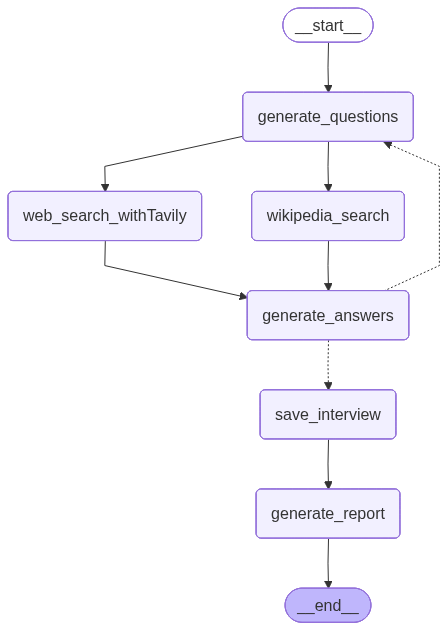

In [30]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

builder = StateGraph(interview_state)
# add nodes
builder.add_node('generate_questions', generate_questions) # ask question to an expert
builder.add_node('web_search_withTavily' , web_search_withTavily) # web search based on the questions (create context)
builder.add_node('wikipedia_search' , wikipedia_search) # wiki search based on the questions (create context)
builder.add_node('generate_answers' , generate_answers) # generate answers based on the questions asked
builder.add_node('save_interview' , save_interview) # save both questions and answers as an interview
builder.add_node('generate_report' , technical_writing) # create a report based on the context from web and wiki search

# add flow or adges
builder.set_entry_point('generate_questions')
builder.add_edge('generate_questions', 'web_search_withTavily') # using the questions websearch to get context
builder.add_edge('generate_questions', 'wikipedia_search') # using the questions wiki search to get context
builder.add_edge('web_search_withTavily', 'generate_answers') # join back to get answers
builder.add_edge('wikipedia_search', 'generate_answers') #  join back to get answers from the context
# save to interview if condition is met
builder.add_conditional_edges('generate_answers' , continue_task , ['save_interview','generate_questions'])
builder.add_edge('save_interview', 'generate_report') #  write a report based on the context
builder.add_edge('generate_report', END) #  end graph

#compile
interview_graph = builder.compile(checkpointer= checkpointer).with_config(run_name = "conduct interview")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

## Continue form original state:overallstate 
- get the analysts list and
- topic for the interview
- continue with ofiginal thread
  

In [31]:
state_new.values

NameError: name 'state_new' is not defined

In [46]:
anlysts = state_new.values['analysts'][-1].analysts
anlysts[0]

NameError: name 'state_new' is not defined

In [162]:
topic = state_new.values['topic']
topic

NameError: name 'state_new' is not defined

In [ ]:
# prepare Human message for MessagesState providing the topic
Human_msg = [HumanMessage(content=f"lets go!")]
interview = interview_graph.invoke({'topic' : topic , 'messages': Human_msg , 'analyst': anlysts[0] , 'max_turns' : 3 }, config )


In [ ]:
print(interview)


In [ ]:
from IPython.display import Markdown
Markdown(interview['interview'])

In [ ]:
Markdown(interview_graph.get_state(config).values['technical_report'][-1])

## Step 3: Parallelize Interview

-  After the anlysts tate created for subtopics, assign them to conduct the interview parallely

In [115]:
# create a class for routing and reporting
class ResearchGraphState(TypedDict):
    topic: str
    max_analyst:int
    analysts : List[Analyst] # List[Analyst.persona* max_analyst] / annotated for persistance
    human_analyst_feedback: str
    interview: Annotated[List[str],add]
    technical_report: Annotated[list[str],add]  # map-reduce : spend API- technical report from various analysts interviewd in subgraph
    conclusion: str
    introduction:List[str]
    #final_content: str
    Final_Report:str
    
# re-write feedback loop to creae analyst
# map-reduce analysts to interview subgraph(conduct_interview)
from langgraph.types import Send # updated in 1.0

def feedback_or_interview(state:ResearchGraphState)->Literal['create_analysts' , 'conduct_interview']:
    ''' continue to create analyst node if feedback exists or conduct interview'''
    feedback = state.get('human_analyst_feedback' , None)
    if feedback:
        print("Feedback_Analysts:{feedback}")
        return 'create_analysts'
        
    else: 
        initial_msg = [HumanMessage(content="Lets begin the interview on the topic: '{state['topic']}'")]
        #print(state['topic'])
        return [Send('conduct_interview' , {'analyst': analyst ,'messages':initial_msg, 'max_turns' : 2}) for analyst in state['analysts']]
  

# reduce the output from map
conclusion_prompt= ''' You are a Technical Report Conclusion Writer.

Your task is to read and synthesize the combined technical reports produced by multiple analysts on the topic  and subtopics.

Each analyst report is based on:
- Context gathered from web search and Wikipedia
- Interview-style Q&A where analysts reasoned through the topic
- Their own domain-specific analytical perspective

You will receive a list of analyst reports under the variable **{reports}**.
Your goal is to write a clear, insightful, and authoritative **Conclusion Section** for the final technical report.

### Your Responsibilities

1. **Synthesize Across Analysts**
   - Identify common themes, agreements, and shared findings.
   - Highlight complementary insights across analysts.
   - Resolve contradictions or differing viewpoints neutrally and analytically.

2. **Reflect the Evidence**
   - Base your conclusion ONLY on what appears in the analyst reports.
   - Do not invent facts or introduce new research.
   - Emphasize how the combined evidence supports the final understanding of the topic.

3. **Provide a Strong Closing Perspective**
   - Summarize the overall significance of the findings.
   - State the final takeaways that a reader should remember.
   - Optionally include forward-looking implications or recommendations if supported by the reports.
 

### Writing Requirements

- Write in **professional technical-report style**.
- Use **Markdown** formatting.
- Keep the tone analytical, concise, and authoritative.
- Do NOT repeat the full content of the reports—summarize and synthesize.
- Include citations as 
[1] source 
[2] source

### Output Format

Produce only the following section:

## Conclusion
your synthesized conclusion here
'''

# structured output
class Report(BaseModel):
    report:str
    
def report_conclusion(state:ResearchGraphState):
    reports = state['technical_report'] # list of reports
    joined_report = "\n\n".join([report for report in reports])
    #print("Reports:", reports)
    # system instruction for LLM
    sys_in = SystemMessage(content=conclusion_prompt.format(reports = joined_report))

    response = llm.with_structured_output(Report).invoke([sys_in] + [HumanMessage(content="Generate a conclusion report ")])
    return {'conclusion': response.report }

introduction_prompt = '''You are a Senior Technical Writer responsible for crafting the **Introduction** section of a research report.

You will be provided with:
- **Topic**: {topic}
- **Technical Reports** generated by multiple analysts after their interviews: {technical_reports}
- **Interview Transcripts** (questions + answers): {interviews}

Your task is to write a clear, authoritative, and well‑structured **Introduction** that sets the stage for the full report.

-----------------------------------
### 🔍 Your Responsibilities

1. **Establish Context**
   - Introduce the main topic in a way that is accessible to a broad technical audience.
   - Explain *why the topic matters* in today’s landscape (industry, research, societal impact).

2. **Summarize the Research Scope**
   - Identify the major themes and angles explored by the analysts.
   - Highlight the diversity of perspectives revealed in the interviews.
   - Explain what aspects of the topic the report will cover.

3. **Synthesize, Don’t Repeat**
   - Do NOT copy or restate the technical reports verbatim.
   - Instead, extract the shared insights, patterns, and overarching narrative.
   - Resolve contradictions neutrally if analysts disagreed.

4. **Connect Interviews to the Topic**
   - Briefly describe how the interviews contributed to understanding the topic.
   - Mention the types of questions explored (without listing them).
   - Emphasize the value of expert reasoning and evidence‑based analysis.

5. **Set Expectations for the Reader**
   - Describe what the reader will gain from the report.
   - Provide a roadmap of what the upcoming sections will address.

-----------------------------------
### 🧱 Writing Requirements

- Write in **professional technical‑report style**.
- Use **Markdown** formatting.
- Tone: clear, analytical, confident, and objective.
- Length: 3–6 paragraphs.
- Avoid marketing language, hype, or filler.
- Do NOT introduce new facts not present in the technical reports or interviews.
- Do NOT include citations or URLs.

-----------------------------------
### 📌 Output Format

Produce ONLY the following section:

## Introduction
your introduction here

'''
# create a blue print
class Intro(BaseModel):
    intro: str

# generate introduction
def report_introduction(state:ResearchGraphState):
    ''' Create introduction section of the report'''

    tech_reports = "\n \n".join([report for report in state['technical_report']])
    
    sys_intr = SystemMessage(content= introduction_prompt.format(topic = state['topic'] , technical_reports = tech_reports , interviews= state['interview']))
    response = llm.with_structured_output(Intro).invoke([sys_intr]+ [HumanMessage(content="Write a Introduction section")])
    
    return {'introduction': response.intro }

# generate Final Report

Final_report_prompt = ''' You are a Senior Research Writer tasked with generating a complete, polished, and easy‑to‑understand **Final Research Report**.

You will be provided with:
- **Topic**: {topic}
- **Introduction Section**: {introduction}
- **Technical Reports** generated by multiple analysts: {technical_reports}
- **Interview Transcripts** (questions + answers): {interviews}
- **Conclusion Section**: {conclusion}

Your job is to synthesize all of this information into a single, coherent, well‑structured research report.

-----------------------------------------
### 🔍 STRICT RULES

1. **Use ONLY the information provided**  
   - Do NOT add new facts.  
   - Do NOT hallucinate.  
   - Every claim must be grounded in the provided documents.

2. **Use Markdown formatting**  
   - # Headings  
   - ## Subheadings  
   - Bullet points  (important)
   - Tables (if needed)  
   - Bold/italics for emphasis (if needed)
   -  Do not make everything bold. 
   - Ensure markdown is proffesional

3. **Use inline source citations at the end of the report**  
    - List your sources in order and do not repeat.
[1] Source 1
[2] Source 2 
   - Every factual statement must reference one of the provided documents.

4. **Synthesize, don’t repeat**  
   - Combine insights across analysts.  
   - Highlight patterns, agreements, contradictions.  
   - Extract meaning, not raw text.

5. **Write for clarity**  
   - Easy to understand  
   - Logical flow  
   - no pre-amble
   - No jargon unless explained  
   - Focus on insights and implications  

-----------------------------------------
### 🧱 REPORT STRUCTURE

Produce the report in the following structure:

# {topic}

## Introduction
Use the provided introduction exactly as given, but you may lightly refine for flow and clarity.  
*(Cite sources at the end of the report refereing to introductionsection )*

## Key Insights From Analyst Reports
Synthesize the major findings across all technical reports.  
Highlight:
- Shared themes  
- Unique perspectives  
- Contradictions or disagreements  
- Evidence‑based insights  
Use citations for every claim.

## Insights From Expert Interviews
Summarize what the interviews revealed:
- Important answers  
- Expert reasoning  
- Context gathered from web + wiki search  
- How the interviews deepened understanding  
Cite each insight with the appropriate interview source.

## Integrated Analysis
Combine the technical reports + interviews:
- What do they collectively reveal?  
- What patterns emerge?  
- What implications matter most?  
- What gaps or limitations exist?  
Use citations throughout.

## Conclusion
Use the provided conclusion, but you may refine for clarity and coherence.  
Ensure it aligns with the evidence presented.

## Citation
[1] source 1
[2] source 2
-----------------------------------------
### 📌 OUTPUT REQUIREMENTS

- Produce a **single, unified Markdown report**.
- Include **inline citations** for every factual statement.
- Do NOT invent any information.
- Do not skip insights and major information.
- Focus on clarity, insight, and evidence.
-  MAke the report easily digestible  and easy to read.

'''
# blue print for structured output
class Final(BaseModel):
    final_report:str

def Final_Report(state:ResearchGraphState):
    ''' Create Final Report'''

    tech_reports = "\n \n".join([report for report in state['technical_report']])
    Interview = state['interview']
    intro = state['introduction']
    conclu = state['conclusion']
    
    sys_intr = SystemMessage(content= Final_report_prompt.format(topic = state['topic'] , technical_reports = tech_reports , interviews= Interview , introduction = intro, conclusion = conclu))
    response = llm.with_structured_output(Final).invoke([sys_intr]+ [HumanMessage(content=" Gnerate a Final Report ")])
    
    return {'Final_Report': response.final_report }



#### Build main graph

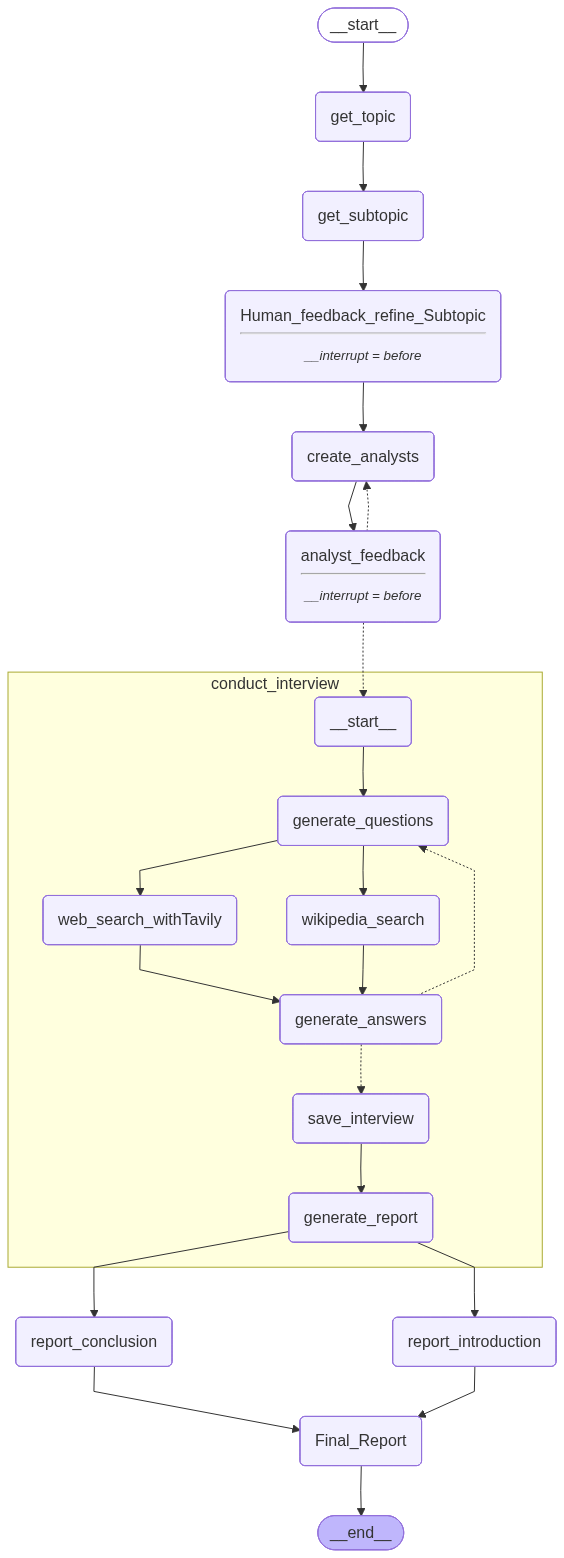

In [116]:
main_builder = StateGraph(ResearchGraphState)


main_builder.add_node('get_topic' , get_topic)
main_builder.add_node('get_subtopic' , get_subtopic)
main_builder.add_node('Human_feedback_refine_Subtopic' , Human_feedback_refine_Subtopic)
main_builder.add_node('create_analysts' , create_analysts)
main_builder.add_node('analyst_feedback' , analyst_feedback)
main_builder.add_node('conduct_interview' , interview_graph)
main_builder.add_node('report_conclusion' , report_conclusion)
main_builder.add_node('report_introduction' , report_introduction)
main_builder.add_node('Final_Report' , Final_Report)

# add condition
main_builder.add_edge(START,'get_topic')
main_builder.add_edge('get_topic', 'get_subtopic')
main_builder.add_edge('get_subtopic', 'Human_feedback_refine_Subtopic')
main_builder.add_edge('Human_feedback_refine_Subtopic', 'create_analysts')
main_builder.add_edge('create_analysts', 'analyst_feedback')
main_builder.add_conditional_edges('analyst_feedback', feedback_or_interview, ['create_analysts' , 'conduct_interview'] )
main_builder.add_edge('conduct_interview', 'report_conclusion')
main_builder.add_edge('conduct_interview' , 'report_introduction')
main_builder.add_edge('report_introduction' , 'Final_Report')
main_builder.add_edge('report_conclusion' , 'Final_Report')
main_builder.add_edge('Final_Report', END)

main_graph = main_builder.compile(interrupt_before=['Human_feedback_refine_Subtopic', 'analyst_feedback'], checkpointer = memory).with_config(run_name = "report_generation")
# View
display(Image(main_graph.get_graph(xray=1).draw_mermaid_png()))


#### Invoke graph

In [117]:

config = {'configurable': {'thread_id': '10'}}
events = []
# state input
OverallState_Input = { 
    'max_analyst':3
}
for event in main_graph.stream(OverallState_Input , config=config, stream_mode="values"):
    events.append(event)
    print(event)
    print("-"*45)

{'max_analyst': 3, 'interview': [], 'technical_report': []}
---------------------------------------------


What Topic are you interested in exploring and generating a report on? We have expert Analysts team to genetate reports for you based on your topic.
 Your topic:  Agentic frameowrk


{'topic': 'Agentic frameowrk', 'max_analyst': 3, 'interview': [], 'technical_report': []}
---------------------------------------------
{'topic': 'Agentic frameowrk', 'max_analyst': 3, 'interview': [], 'technical_report': [], 'subtopics': ['Autonomous decision-making architectures', 'Multi-agent collaboration and communication protocols', 'Human-in-the-loop oversight and alignment mechanisms']}
---------------------------------------------


In [118]:
events

[{'max_analyst': 3, 'interview': [], 'technical_report': []},
 {'topic': 'Agentic frameowrk',
  'max_analyst': 3,
  'interview': [],
  'technical_report': []},
 {'topic': 'Agentic frameowrk',
  'max_analyst': 3,
  'interview': [],
  'technical_report': [],
  'subtopics': ['Autonomous decision-making architectures',
   'Multi-agent collaboration and communication protocols',
   'Human-in-the-loop oversight and alignment mechanisms']}]

In [119]:
main_graph.get_state(config).next

('Human_feedback_refine_Subtopic',)

In [120]:
main_graph.update_state(config , {'subtopic_feedback':"substitute a subtopic with a subtopic about RAG in healthcare" })
for event in main_graph.stream(None , config=config, stream_mode="values"):
    print(event)
    print("-"*40)

{'topic': 'Agentic frameowrk', 'max_analyst': 3, 'interview': [], 'technical_report': [], 'subtopics': ['Autonomous decision-making architectures', 'Multi-agent collaboration and communication protocols', 'Human-in-the-loop oversight and alignment mechanisms'], 'subtopic_feedback': 'substitute a subtopic with a subtopic about RAG in healthcare'}
----------------------------------------
{'topic': 'Agentic frameowrk', 'max_analyst': 3, 'interview': [], 'technical_report': [], 'subtopics': ['Autonomous decision-making architectures in healthcare', 'RAG-enhanced multi-agent collaboration for clinical diagnostics', 'Human-in-the-loop oversight and alignment mechanisms'], 'subtopic_feedback': 'substitute a subtopic with a subtopic about RAG in healthcare'}
----------------------------------------
{'topic': 'Agentic frameowrk', 'max_analyst': 3, 'analysts': [Analyst(name='Dr. Elena Vance', role='Lead Architect of Autonomous Clinical Systems', affiliation='Institute for Advanced Medical Roboti

In [121]:
for a in main_graph.get_state(config).values['analysts']:
    print(a)
    print("\n")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


name='Dr. Elena Vance' role='Lead Architect of Autonomous Clinical Systems' affiliation='Institute for Advanced Medical Robotics' description='Specializes in the design of decentralized decision-making frameworks for high-stakes healthcare environments, focusing on fault-tolerant logic and real-time clinical safety protocols.'


name='Dr. Marcus Thorne' role='Senior Researcher in Multi-Agent Knowledge Synthesis' affiliation='Global Health Informatics Consortium' description='Expert in RAG-enhanced agentic workflows, dedicated to optimizing how multi-agent systems retrieve and synthesize vast medical literature to improve diagnostic accuracy and reduce cognitive load for clinicians.'


name='Dr. Sarah Jenkins-Wu' role='Director of Human-AI Alignment and Ethics' affiliation='Center for Algorithmic Governance in Medicine' description='Focuses on the intersection of human-in-the-loop oversight and ethical alignment, ensuring that autonomous agentic frameworks remain subservient to clinical

In [111]:
main_graph.get_state(config).next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


('analyst_feedback',)

### provide feedback for analyst creation

In [51]:
main_graph.update_state(config , {'human_analyst_feedback':"replace an analyst with someone from the startup venture capital" })


Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '4',
  'checkpoint_ns': '',
  'checkpoint_id': '1f159206-ce3d-62b0-8006-b429d6f65423'}}

In [52]:
for event in main_graph.stream(None , config=config, stream_mode="values"):
    result = "\n-\n".join([str(a)for a in event['analysts']])
    print(result)
    print("-"*40)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


name='Dr. Elena Vance' role='Lead Data Scientist and Visualization Architect' affiliation='Institute for Advanced Statistical Modeling' description='Specializes in transforming complex datasets into actionable insights using Python libraries like Pandas, Matplotlib, and Plotly, with a focus on high-dimensional data storytelling.'
-
name='Prof. Marcus Thorne' role='Senior Full-Stack Framework Engineer' affiliation='Global Web Infrastructure Consortium' description='Expert in scalable backend architecture using Django and Flask, focusing on secure API development, microservices integration, and optimizing Python-based web performance for high-traffic applications.'
-
name='Dr. Sarah Jenkins-Wu' role='Principal AI Researcher in Clinical Informatics' affiliation='Center for Digital Health Innovation' description='Dedicated to the intersection of Python-based machine learning and patient care, focusing on predictive diagnostics, medical imaging analysis, and the ethical deployment of AI in 

In [112]:
main_graph.get_state(config).next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


('analyst_feedback',)

In [125]:
main_graph.update_state(config , {'human_analyst_feedback':None })
for event in main_graph.stream(None , config=config, stream_mode="values"):
    result = {"\n \n".join([f"{key}: {value} " for key, value in event.items()])}
    

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to 

Search_querry:  mathematical frameworks for human-in-the-loop control thresholds in autonomous clinical AI systems to ensure patient-centric safety and ethical alignment
Search_querry:  multi-agent systems for resolving conflicting medical research data synthesis and evidence-based medicine contradictions
Search_querry:  mathematical quantification of epistemic uncertainty in clinical AI decision-making and ethical thresholds for human-in-the-loop intervention
Search_querry:  challenges of integrating human physiological variability into decentralized autonomous clinical systems and fault-tolerant medical AI architecture
Search_querry:  architectures for multi-agent systems to distinguish between scientific disagreement and hallucinated contradictions in medical literature synthesis
Search_querry:  architectural frameworks for decentralized autonomous clinical systems distinguishing benign physiological anomalies from critical failures requiring immediate intervention


In [126]:
from IPython.display import Markdown
state = main_graph.get_state(config)
Markdown(state.values['Final_Report'])

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


# Agentic Framework

## Introduction
The rapid integration of agentic frameworks into clinical environments marks a pivotal shift in healthcare technology, moving from static, rule-based algorithms toward complex, decentralized cyber-physical ecosystems. As these systems assume greater roles in diagnostic workflows and patient monitoring, the imperative to ensure clinical safety, reliability, and human-centric oversight has become the primary challenge for researchers and practitioners alike. This report examines the architectural requirements for deploying autonomous agents in high-stakes medical settings, focusing on the balance between technological innovation and the preservation of professional clinical judgment. The scope of this research encompasses three critical dimensions of agentic integration: the design of fault-tolerant decentralized architectures, the optimization of multi-agent diagnostic workflows, and the implementation of robust human-in-the-loop oversight mechanisms. Through expert interviews and empirical analysis, this report synthesizes current strategies for managing the inherent unpredictability of human physiology and the technical vulnerabilities of large language model-based systems. Key themes include the mitigation of information loss during synthesis, the resolution of conflicting medical data, and the mathematical quantification of uncertainty to define thresholds for human intervention. By exploring these areas, the report provides a comprehensive overview of how healthcare institutions can transition toward a model of 'Reflective AI.'

## Key Insights From Analyst Reports
- **Decentralized Resilience:** Moving away from rigid, centralized models is essential for safety. A unified framework utilizing blockchain for audit trails, edge computing for latency, and AI-driven analytics is recommended to manage clinical complexity [1, 5].
- **Diagnostic Vulnerabilities:** Multi-agent systems (MAS) often suffer from systemic failure patterns, including "information loss" during synthesis and "minority opinion suppression," where majority bias silences correct dissenting views [7].
- **Flawed Consensus:** Current MAS rely heavily on simple voting mechanisms rather than evidence-based argument evaluation, leading to self-contradictory outputs and a lack of cross-turn memory [7].
- **Human-in-the-Loop (HITL) Necessity:** AI must remain subservient to clinical judgment. Frameworks for continuous validation are required to determine when to deploy, pause, or roll back AI tools based on performance metrics [13].
- **Uncertainty Quantification:** Uncertainty should be treated as an inherent property of medical knowledge. Advanced probabilistic methods, such as Bayesian inference and semantic entropy, are required to distinguish between epistemic and aleatoric uncertainties [15].

## Insights From Expert Interviews
- **Physiological Balancing:** Dr. Vance emphasizes that AI must account for diverse sociologic and economic factors to ensure equitable outcomes. Security is the paramount concern, requiring architectures that reduce the risk burden on medical staff [3].
- **Architectural Logic:** To distinguish between benign anomalies and critical failures, experts advocate for edge computing integrated with decentralized autonomous systems, which allows for real-time processing that rule-based systems cannot match [3, 4, 5].
- **Managing Contradictions:** Dr. Thorne notes that current diagnostic frameworks are vulnerable to ineffective discussion dynamics. Future systems must prioritize evidence-based evaluation over aggregation to prevent model-induced hallucinations from being treated as scientific fact [7].
- **Governance Thresholds:** Dr. Jenkins-Wu highlights that the threshold for human intervention should be dynamic. By using probabilistic methods to compute semantic entropy, hospitals can establish clear, ethically responsible margins where AI confidence is insufficient, necessitating human oversight [15].

## Integrated Analysis
The synthesis of technical reports and expert interviews reveals a clear consensus: the transition to agentic healthcare requires moving beyond simple data aggregation toward 'Reflective AI.' 
- **Patterns:** A recurring theme is the failure of majority-voting mechanisms in multi-agent systems, which mirrors the need for more sophisticated, evidence-based evaluation protocols [7].
- **Implications:** The shift toward decentralized architectures is not merely a technical upgrade but a necessary governance strategy to redistribute responsibility, ensuring that clinicians are supported rather than replaced [3, 5].
- **Gaps:** A significant gap remains in the "cross-turn memory" of current agents, which leads to self-contradiction. Addressing this is critical for maintaining the integrity of domain-specific expertise during complex diagnostic workflows [7].
- **Conclusion on Safety:** The integration of blockchain for auditability and Bayesian inference for uncertainty quantification provides a robust, multi-layered approach to managing high-stakes clinical risk [1, 15].

## Conclusion
The integration of autonomous AI into clinical environments represents a transition from centralized, rigid algorithms to decentralized, fault-tolerant cyber-physical ecosystems. Synthesizing the evidence, it is clear that while multi-agent systems offer significant potential for diagnostic efficiency, they are currently hindered by systemic vulnerabilities such as information loss, consensus bias, and a lack of cross-turn memory [7]. To address these challenges, the field must move toward a 'Reflective AI' paradigm that prioritizes human-in-the-loop (HITL) oversight and rigorous uncertainty quantification [15]. The convergence of blockchain-based audit trails, edge computing, and probabilistic modeling provides a robust foundation for managing clinical risk [1, 5, 15]. By distinguishing between benign anomalies and critical failures, these decentralized frameworks effectively redistribute responsibility, ensuring that AI remains a supportive tool rather than a replacement for professional clinical judgment [3, 4]. Ultimately, the path forward requires moving beyond simple data aggregation toward architectures that incentivize evidence-based reasoning and maintain the integrity of domain-specific expertise [7]. Future clinical safety depends on embedding these decentralized, transparent, and human-accountable protocols into the core of medical infrastructure to ensure that technological autonomy remains strictly bounded by patient-centric values [3, 13].

## Citation
[1] https://www.researchgate.net/figure/The-main-challenges-in-AI-clinical-integration_fig5_360040061
[3] https://pmc.ncbi.nlm.nih.gov/articles/PMC8165857
[4] https://www.clinicalkey.com#!/content/journal/1-s2.0-S0022391323001762
[5] https://pmc.ncbi.nlm.nih.gov/articles/PMC12598492
[7] https://arxiv.org/pdf/2510.10185
[13] https://papers.ssrn.com/sol3/Delivery.cfm/5653830.pdf?abstractid=5653830&mirid=1
[15] https://arxiv.org/html/2504.05278v1

In [127]:
Markdown(state.values['Final_Report'])

# Agentic Framework

## Introduction
The rapid integration of agentic frameworks into clinical environments marks a pivotal shift in healthcare technology, moving from static, rule-based algorithms toward complex, decentralized cyber-physical ecosystems. As these systems assume greater roles in diagnostic workflows and patient monitoring, the imperative to ensure clinical safety, reliability, and human-centric oversight has become the primary challenge for researchers and practitioners alike. This report examines the architectural requirements for deploying autonomous agents in high-stakes medical settings, focusing on the balance between technological innovation and the preservation of professional clinical judgment. The scope of this research encompasses three critical dimensions of agentic integration: the design of fault-tolerant decentralized architectures, the optimization of multi-agent diagnostic workflows, and the implementation of robust human-in-the-loop oversight mechanisms. Through expert interviews and empirical analysis, this report synthesizes current strategies for managing the inherent unpredictability of human physiology and the technical vulnerabilities of large language model-based systems. Key themes include the mitigation of information loss during synthesis, the resolution of conflicting medical data, and the mathematical quantification of uncertainty to define thresholds for human intervention. By exploring these areas, the report provides a comprehensive overview of how healthcare institutions can transition toward a model of 'Reflective AI.'

## Key Insights From Analyst Reports
- **Decentralized Resilience:** Moving away from rigid, centralized models is essential for safety. A unified framework utilizing blockchain for audit trails, edge computing for latency, and AI-driven analytics is recommended to manage clinical complexity [1, 5].
- **Diagnostic Vulnerabilities:** Multi-agent systems (MAS) often suffer from systemic failure patterns, including "information loss" during synthesis and "minority opinion suppression," where majority bias silences correct dissenting views [7].
- **Flawed Consensus:** Current MAS rely heavily on simple voting mechanisms rather than evidence-based argument evaluation, leading to self-contradictory outputs and a lack of cross-turn memory [7].
- **Human-in-the-Loop (HITL) Necessity:** AI must remain subservient to clinical judgment. Frameworks for continuous validation are required to determine when to deploy, pause, or roll back AI tools based on performance metrics [13].
- **Uncertainty Quantification:** Uncertainty should be treated as an inherent property of medical knowledge. Advanced probabilistic methods, such as Bayesian inference and semantic entropy, are required to distinguish between epistemic and aleatoric uncertainties [15].

## Insights From Expert Interviews
- **Physiological Balancing:** Dr. Vance emphasizes that AI must account for diverse sociologic and economic factors to ensure equitable outcomes. Security is the paramount concern, requiring architectures that reduce the risk burden on medical staff [3].
- **Architectural Logic:** To distinguish between benign anomalies and critical failures, experts advocate for edge computing integrated with decentralized autonomous systems, which allows for real-time processing that rule-based systems cannot match [3, 4, 5].
- **Managing Contradictions:** Dr. Thorne notes that current diagnostic frameworks are vulnerable to ineffective discussion dynamics. Future systems must prioritize evidence-based evaluation over aggregation to prevent model-induced hallucinations from being treated as scientific fact [7].
- **Governance Thresholds:** Dr. Jenkins-Wu highlights that the threshold for human intervention should be dynamic. By using probabilistic methods to compute semantic entropy, hospitals can establish clear, ethically responsible margins where AI confidence is insufficient, necessitating human oversight [15].

## Integrated Analysis
The synthesis of technical reports and expert interviews reveals a clear consensus: the transition to agentic healthcare requires moving beyond simple data aggregation toward 'Reflective AI.' 
- **Patterns:** A recurring theme is the failure of majority-voting mechanisms in multi-agent systems, which mirrors the need for more sophisticated, evidence-based evaluation protocols [7].
- **Implications:** The shift toward decentralized architectures is not merely a technical upgrade but a necessary governance strategy to redistribute responsibility, ensuring that clinicians are supported rather than replaced [3, 5].
- **Gaps:** A significant gap remains in the "cross-turn memory" of current agents, which leads to self-contradiction. Addressing this is critical for maintaining the integrity of domain-specific expertise during complex diagnostic workflows [7].
- **Conclusion on Safety:** The integration of blockchain for auditability and Bayesian inference for uncertainty quantification provides a robust, multi-layered approach to managing high-stakes clinical risk [1, 15].

## Conclusion
The integration of autonomous AI into clinical environments represents a transition from centralized, rigid algorithms to decentralized, fault-tolerant cyber-physical ecosystems. Synthesizing the evidence, it is clear that while multi-agent systems offer significant potential for diagnostic efficiency, they are currently hindered by systemic vulnerabilities such as information loss, consensus bias, and a lack of cross-turn memory [7]. To address these challenges, the field must move toward a 'Reflective AI' paradigm that prioritizes human-in-the-loop (HITL) oversight and rigorous uncertainty quantification [15]. The convergence of blockchain-based audit trails, edge computing, and probabilistic modeling provides a robust foundation for managing clinical risk [1, 5, 15]. By distinguishing between benign anomalies and critical failures, these decentralized frameworks effectively redistribute responsibility, ensuring that AI remains a supportive tool rather than a replacement for professional clinical judgment [3, 4]. Ultimately, the path forward requires moving beyond simple data aggregation toward architectures that incentivize evidence-based reasoning and maintain the integrity of domain-specific expertise [7]. Future clinical safety depends on embedding these decentralized, transparent, and human-accountable protocols into the core of medical infrastructure to ensure that technological autonomy remains strictly bounded by patient-centric values [3, 13].

## Citation
[1] https://www.researchgate.net/figure/The-main-challenges-in-AI-clinical-integration_fig5_360040061
[3] https://pmc.ncbi.nlm.nih.gov/articles/PMC8165857
[4] https://www.clinicalkey.com#!/content/journal/1-s2.0-S0022391323001762
[5] https://pmc.ncbi.nlm.nih.gov/articles/PMC12598492
[7] https://arxiv.org/pdf/2510.10185
[13] https://papers.ssrn.com/sol3/Delivery.cfm/5653830.pdf?abstractid=5653830&mirid=1
[15] https://arxiv.org/html/2504.05278v1